# Set Up

In [7]:
import mlflow
import os
import pandas as pd
import json

In [8]:
import sys
sys.path.append("../src")

from train_and_tune import (
    LinearRegressionTrainer,
    XGBTrainer,
    RandomForestTrainer,
    time_sorted_split
)
from pipeline import build_dataset


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
mlflow.set_tracking_uri("sqlite:///C:/Dev/taxi-fare-predictor/mlflow.db")
mlflow.set_experiment("taxi-fare-prediction")

<Experiment: artifact_location='file:c:/Dev/taxi-fare-predictor/notebooks/mlruns/1', creation_time=1786302150001, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1786302150001, lifecycle_stage='active', name='taxi-fare-prediction', tags={}, trace_location=None, workspace='default'>

In [11]:
# index to sort trip time/dates on
TIME_SORT_INDEX = 'tpep_pickup_datetime'

In [12]:
# proportion of data used for testing
TEST_PROPORTION = 0.2

In [13]:
# Features
TARGET = 'fare_amount'
NUMERICAL_FEATURES = ['trip_duration', 'passenger_count', 'trip_distance']
CATEGORICAL_FEATURES = ['pickup_borough', 'dropoff_borough', 'rate_category', 'pickup_hour', 'pickup_dayofweek']

In [14]:
df = build_dataset()

X_train, y_train, X_test, y_test = time_sorted_split(
    df,
    num_features=NUMERICAL_FEATURES,
    cat_features=CATEGORICAL_FEATURES,
    target=TARGET,
    sort_index=TIME_SORT_INDEX,
    test_proportion=TEST_PROPORTION
)

## Linear Regression Initial Fit

In [15]:
trainer = LinearRegressionTrainer()

with mlflow.start_run(run_name="LinearRegression"):
    trainer.train(X_train, y_train)
    trainer.evaluate(X_train, y_train, X_test, y_test)
    trainer.log_to_mlflow(params={})
    trainer.print_results()


2026/08/24 21:47:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Train RMSE: 4.150 | Test RMSE: 4.874 | Gap: 0.725
Train R2: 0.938 | Test R2: 0.914


## XGBoost Initial Fit

In [16]:
XG_N_ESTIMATORS = 300
XG_LEARNING_RATE = 0.05
XG_MAX_DEPTH = 6
XG_SUBSAMPLE = 0.8
XG_COLSAMPLE_BYTREE = 0.8

In [17]:
trainer = XGBTrainer(
    n_estimators=XG_N_ESTIMATORS,
    learning_rate=XG_LEARNING_RATE,
    max_depth=XG_MAX_DEPTH,
    subsample=XG_SUBSAMPLE,
    colsample_bytree=XG_COLSAMPLE_BYTREE
)

with mlflow.start_run(run_name="XGBoost"):
    trainer.train(X_train, y_train)
    trainer.evaluate(X_train, y_train, X_test, y_test)
    trainer.log_to_mlflow(params={
        "n_estimators": XG_N_ESTIMATORS,
        "learning_rate": XG_LEARNING_RATE,
        "max_depth": XG_MAX_DEPTH,
        "subsample": XG_SUBSAMPLE,
        "colsample_bytree": XG_COLSAMPLE_BYTREE
    })
    trainer.print_results()


2026/08/24 21:48:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Train RMSE: 1.923 | Test RMSE: 2.232 | Gap: 0.309
Train R2: 0.987 | Test R2: 0.982


## Random Forest Initial Fit

In [18]:
RF_N_ESTIMATORS = 200
RF_MAX_DEPTH = 6
RF_MIN_SAMPLES_LEAF = 1
RF_MAX_FEATURES = 'sqrt'

In [19]:
trainer = RandomForestTrainer(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF,
    max_features=RF_MAX_FEATURES
)

with mlflow.start_run(run_name="RandomForest"):
    trainer.train(X_train, y_train)
    trainer.evaluate(X_train, y_train, X_test, y_test)
    trainer.log_to_mlflow(params={
        "n_estimators": RF_N_ESTIMATORS,
        "max_depth": RF_MAX_DEPTH,
        "min_samples_leaf": RF_MIN_SAMPLES_LEAF,
        "max_features": RF_MAX_FEATURES
    })
    trainer.print_results()


KeyboardInterrupt: 

## Initial Comparison

The following table summaries the inital metrics of the three models after a first fit. We have the root mean squared error (RMSE), mean average error (MAE) and the R2 score for both the test and train run. 

In [ ]:
experiment_name = "taxi-fare-prediction"
experiment = mlflow.get_experiment_by_name(experiment_name)

df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
df = df.head(3)

metrics_df = df[[
    "run_id",
    "params.model_type",
    "metrics.train_rmse",
    "metrics.test_rmse",
    "metrics.train_mae",
    "metrics.test_mae",
    "metrics.train_r2",
    "metrics.test_r2",
    "metrics.rmse_gap"
]]

metrics_df.sort_values("metrics.test_rmse")



,run_id,params.model_type,metrics.train_rmse,metrics.test_rmse,metrics.train_mae,metrics.test_mae,metrics.train_r2,metrics.test_r2,metrics.rmse_gap
1,0e98c4d627b646a3b2cbe28e3cb9c16a,XGBRegressor,1.926094,2.233215,0.688769,0.807676,0.986622,0.981901,0.307121
2,c275a11457d444c2994650e98126f946,LinearRegression,4.149665,4.874208,2.152139,2.730622,0.937904,0.913783,0.724543
0,baad10718e3d4e8c88adb56432e831f3,RandomForestRegressor,5.029895,5.839151,3.216442,3.597335,0.908767,0.876267,0.809256


The following graphs show the RMSE and R2 score of the training and testing runs of all the models.

Plot already exists — skipping save.


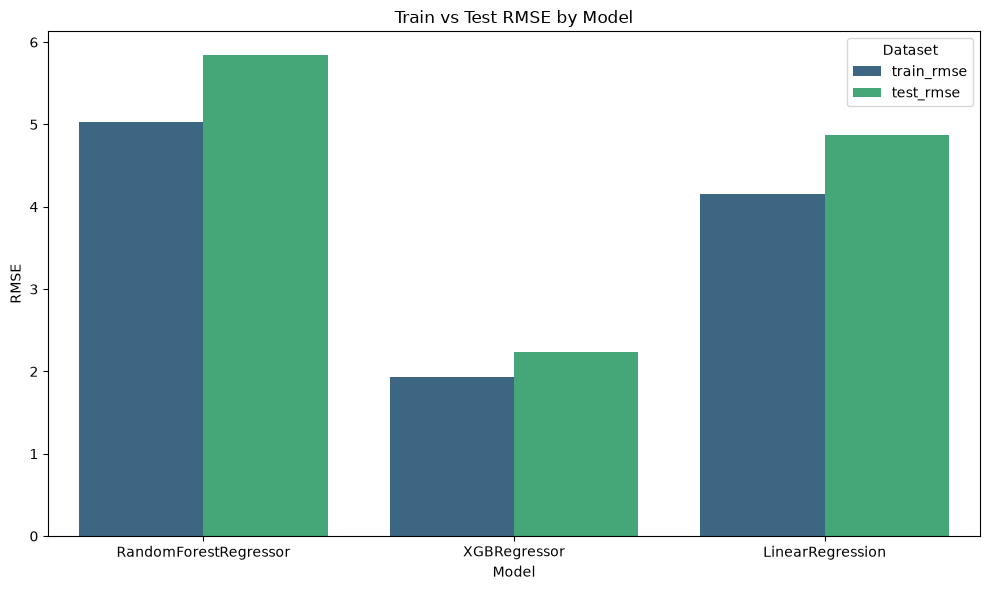

In [ ]:
rmse_df = df[[
    "params.model_type",
    "metrics.train_rmse",
    "metrics.test_rmse"
]].copy()
rmse_df.columns = ["model", "train_rmse", "test_rmse"]
rmse_long = rmse_df.melt(
    id_vars="model",
    value_vars=["train_rmse", "test_rmse"],
    var_name="dataset",
    value_name="rmse"
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=rmse_long,
    x="model",
    y="rmse",
    hue="dataset",
    palette="viridis"
)

plt.title("Train vs Test RMSE by Model")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.legend(title="Dataset")
plt.tight_layout()

save_path_RMSE = "../Graphs/Initial_RMSE_by_Model.png"

if not os.path.exists(save_path_RMSE):
    plt.savefig(save_path_RMSE, dpi=300, bbox_inches="tight")
    print("Saved plot.")
else:
    print("Plot already exists — skipping save.")

plt.show()



Plot already exists — skipping save.


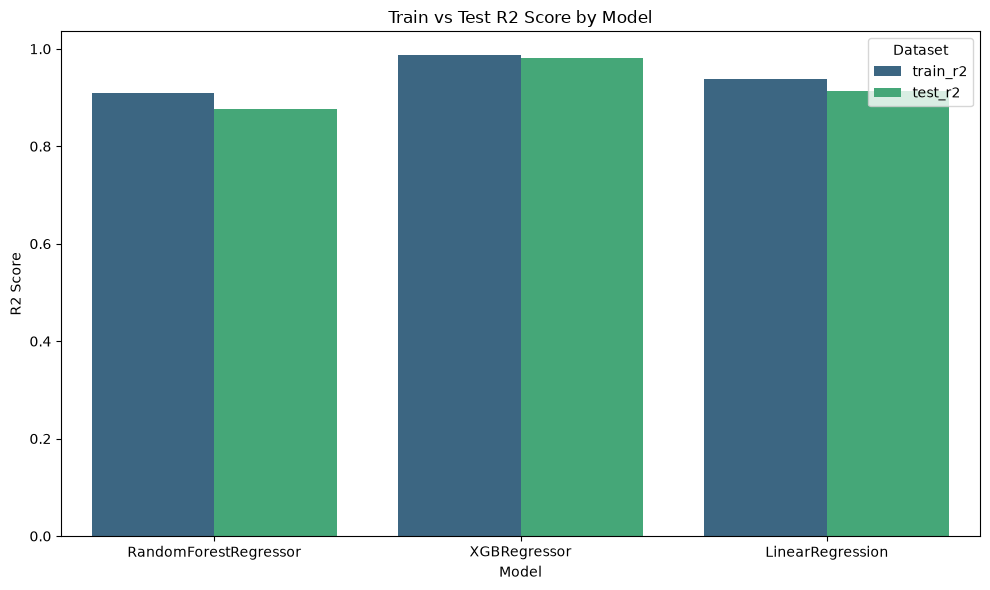

In [ ]:
r2_df = df[[
    "params.model_type",
    "metrics.train_r2",
    "metrics.test_r2"
]].copy()
r2_df.columns = ["model", "train_r2", "test_r2"]
r2_long = r2_df.melt(
    id_vars="model",
    value_vars=["train_r2", "test_r2"],
    var_name="dataset",
    value_name="r2"
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=r2_long,
    x="model",
    y="r2",
    hue="dataset",
    palette="viridis"
)

plt.title("Train vs Test R2 Score by Model")
plt.ylabel("R2 Score")
plt.xlabel("Model")
plt.legend(title="Dataset")
plt.tight_layout()

save_path_R2 = "../Graphs/Initial_R2_by_Model.png"

if not os.path.exists(save_path_R2):
    plt.savefig(save_path_R2, dpi=300, bbox_inches="tight")
    print("Saved plot.")
else:
    print("Plot already exists — skipping save.")

plt.show()


The XGBoost model has the lowest RMSE error and the highest R2 score which suggests it is the best intital fit to the data.

## XGBoost Hyperparameter Tuning

In [ ]:
xgb_search_space = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

N_ITER = 20
CV = 3


In [ ]:
trainer = XGBTrainer()

with mlflow.start_run(run_name="XGBoost_Tuned"):
    best_params = trainer.tune(
        X_train,
        y_train,
        param_distributions=xgb_search_space,
        n_iter=N_ITER,
        cv=CV,
        scoring='neg_root_mean_squared_error'
    )

    trainer.evaluate(X_train, y_train, X_test, y_test)
    trainer.log_to_mlflow(best_params)
    trainer.print_results()


2026/08/23 17:01:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Train RMSE: 1.818 | Test RMSE: 2.194 | Gap: 0.376
Train R2: 0.988 | Test R2: 0.983


## Random Forest Hyperparameter Tuning

In [ ]:
rf_search_space = {
    "n_estimators": [100, 200, 400],
    "max_depth": [10, 20, 40],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [ ]:
trainer = RandomForestTrainer()

with mlflow.start_run(run_name="RandomForest_Tuned"):
    best_params = trainer.tune(
        X_train,
        y_train,
        param_distributions=rf_search_space,
        n_iter=20,
        scoring='neg_root_mean_squared_error',
        cv=3
    )

    trainer.evaluate(X_train, y_train, X_test, y_test)
    trainer.log_to_mlflow(best_params)
    trainer.print_results()

c:\Dev\taxi-fare-predictor\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
2 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Dev\taxi-fare-predictor\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Dev\taxi-fare-predictor\.venv\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Dev\taxi-fare-predictor\.venv\Lib\site-packages\sklearn\ensemble\_forest.py", line 468

Train RMSE: 1.798 | Test RMSE: 2.503 | Gap: 0.705
Train R2: 0.988 | Test R2: 0.977


# Tuned Model Comparison

Again, we will compare the candidate models on RMSE and R2 score for both training and testing after hyperparameyer tuning. 

In [ ]:
mlflow.search_runs()

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.test_r2,metrics.test_rmse,metrics.train_mae,metrics.train_r2,...,params.model_type,params.min_samples_leaf,params.colsample_bytree,params.learning_rate,params.subsample,tags.mlflow.user,tags.mlflow.source.name,tags.mlflow.runName,tags.mlflow.source.type,tags.stage
0,9627ac8ff5824710806e0f2735f0c253,1,FINISHED,file:c:/Dev/taxi-fare-predictor/notebooks/mlru...,2026-08-23 16:47:52.938000+00:00,2026-08-23 19:06:06.872000+00:00,0.977268,2.502791,0.630431,0.988345,...,RandomForestRegressor,4,None,None,None,c_reg,model_comparison.ipynb,RandomForest_Tuned,NOTEBOOK,None
1,ce569a8595c54d8cb4fc48dd1cc50457,1,RUNNING,file:c:/Dev/taxi-fare-predictor/notebooks/mlru...,2026-08-23 16:01:47.181000+00:00,NaT,NaN,NaN,NaN,NaN,...,None,None,None,None,None,c_reg,model_comparison.ipynb,RandomForest_Tuned,NOTEBOOK,None
2,982977cd23f54a33a28bcd53afc656a5,1,FINISHED,file:c:/Dev/taxi-fare-predictor/notebooks/mlru...,2026-08-23 15:43:09.799000+00:00,2026-08-23 16:01:47.069000+00:00,0.982532,2.193979,0.658658,0.988083,...,XGBRegressor,None,0.8,0.05,0.8,c_reg,model_comparison.ipynb,production,NOTEBOOK,production
3,baad10718e3d4e8c88adb56432e831f3,1,FINISHED,file:c:/Dev/taxi-fare-predictor/notebooks/mlru...,2026-08-23 15:37:44.236000+00:00,2026-08-23 15:43:08.104000+00:00,0.876267,5.839151,3.216442,0.908767,...,RandomForestRegressor,1,None,None,None,c_reg,model_comparison.ipynb,RandomForest,NOTEBOOK,None
4,0e98c4d627b646a3b2cbe28e3cb9c16a,1,FINISHED,file:c:/Dev/taxi-fare-predictor/notebooks/mlru...,2026-08-23 15:36:53.692000+00:00,2026-08-23 15:37:44.165000+00:00,0.981901,2.233215,0.688769,0.986622,...,XGBRegressor,None,0.8,0.05,0.8,c_reg,model_comparison.ipynb,XGBoost,NOTEBOOK,None
5,c275a11457d444c2994650e98126f946,1,FINISHED,file:c:/Dev/taxi-fare-predictor/notebooks/mlru...,2026-08-23 15:36:17.890000+00:00,2026-08-23 15:36:53.550000+00:00,0.913783,4.874208,2.152139,0.937904,...,LinearRegression,None,None,None,None,c_reg,model_comparison.ipynb,LinearRegression,NOTEBOOK,None


In [ ]:
experiment_name = "taxi-fare-prediction"
experiment = mlflow.get_experiment_by_name(experiment_name)

runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
xgboost_run_id = runs[runs['tags.mlflow.runName'] == 'XGBoost_Tuned'].iloc[0]['run_id']
rf_run_id = runs[runs['tags.mlflow.runName'] == 'RandomForest_Tuned'].iloc[0]['run_id']

In [ ]:
from mlflow.tracking import MlflowClient
client = MlflowClient()

xgboost_run = client.get_run(xgboost_run_id)
rf_run = client.get_run(rf_run_id)

xgboost_params = xgboost_run.data.params
xgboost_metrics = xgboost_run.data.metrics
xgboost_tags = xgboost_run.data.tags

rf_params = rf_run.data.params
rf_metrics = rf_run.data.metrics
rf_tags = rf_run.data.tags

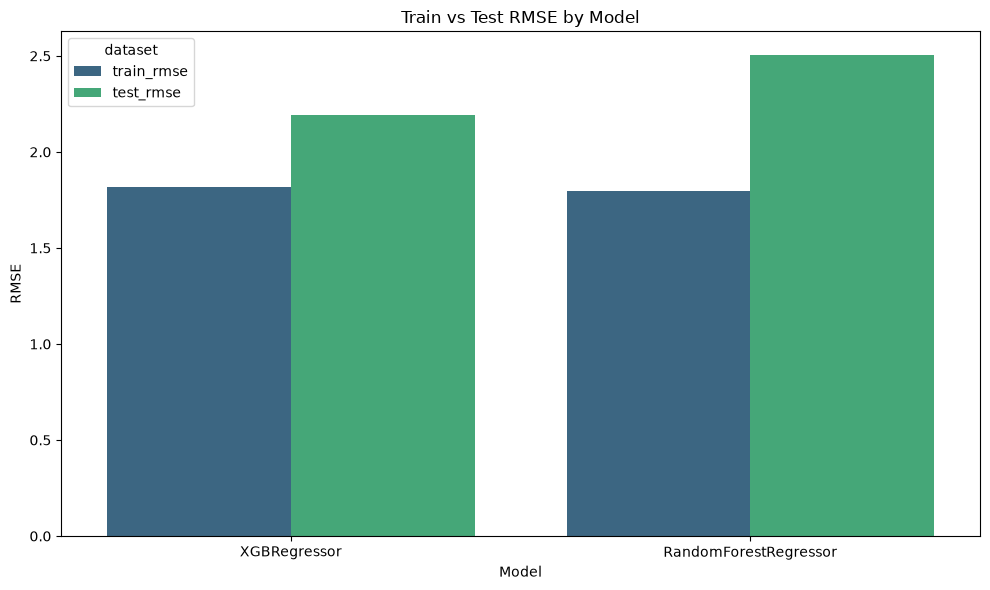

In [ ]:
# Build RMSE comparison DataFrame
rmse_df = pd.DataFrame([
    {
        "model": "XGBRegressor",
        "train_rmse": xgboost_metrics["train_rmse"],
        "test_rmse": xgboost_metrics["test_rmse"]
    },
    {
        "model": "RandomForestRegressor",
        "train_rmse": rf_metrics["train_rmse"],
        "test_rmse": rf_metrics["test_rmse"]
    }
])

# Melt into long format
rmse_long = rmse_df.melt(id_vars="model", var_name="dataset", value_name="rmse")

# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=rmse_long, x="model", y="rmse", hue="dataset", palette="viridis")
plt.title("Train vs Test RMSE by Model")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.tight_layout()

# Save
save_path_rmse = "../Graphs/XGB_RF_RMSE.png"
if not os.path.exists(save_path_rmse):
    plt.savefig(save_path_rmse)
else:
    print("RMSE plot already exists — skipping save.")

plt.show()


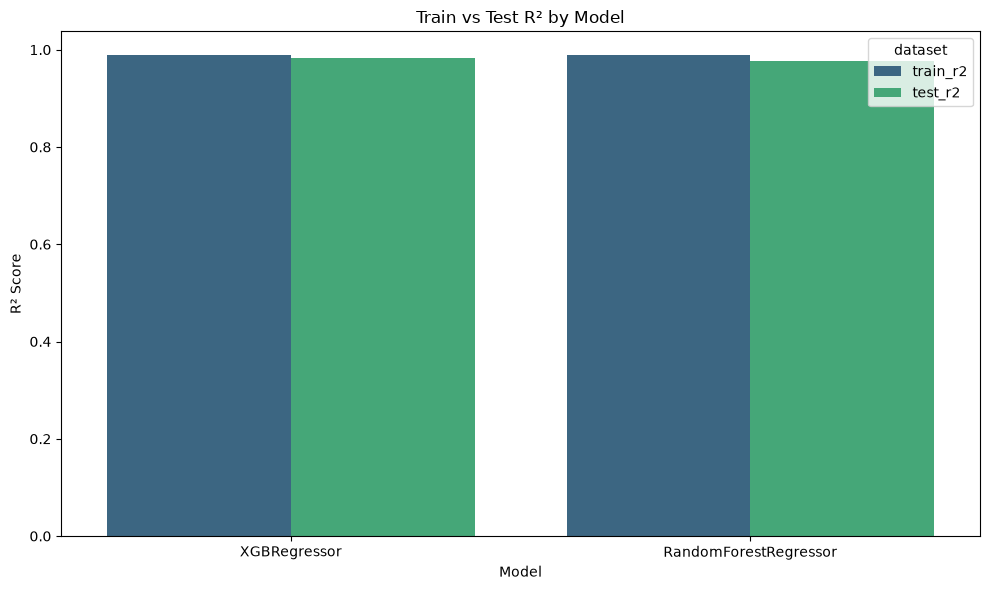

In [ ]:
r2_df = pd.DataFrame([
    {
        "model": "XGBRegressor",
        "train_r2": xgboost_metrics["train_r2"],
        "test_r2": xgboost_metrics["test_r2"]
    },
    {
        "model": "RandomForestRegressor",
        "train_r2": rf_metrics["train_r2"],
        "test_r2": rf_metrics["test_r2"]
    }
])

r2_long = r2_df.melt(id_vars="model", var_name="dataset", value_name="r2")

plt.figure(figsize=(10,6))
sns.barplot(data=r2_long, x="model", y="r2", hue="dataset", palette="viridis")
plt.title("Train vs Test R² by Model")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.tight_layout()

save_path_r2 = "../Graphs/XGB_RF_R2.png"
if not os.path.exists(save_path_r2):
    plt.savefig(save_path_r2)
else:
    print("R² plot already exists — skipping save.")

plt.show()


# Chosen Model

We load our model versioning function that names our chosen model as production etc. We can then load and view the paramaters and metrics for this model.

In [ ]:
training_columns = X_train.columns.tolist()

with open('../data/model_training_columns.json', 'w') as f:
    json.dump(training_columns, f)

print(f"Saved {len(training_columns)} column names")

Saved 52 column names


In [ ]:
from model_versioning import promote_run_to_production

In [ ]:
promote_run_to_production(xgboost_run_id, model_name="taxi-fare-xgboost")

c:\Dev\taxi-fare-predictor\notebooks\../src\model_versioning.py:25: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


True

These are the following parameters chosen by the the RandomisedCVSearch as the best performing combination.

In [ ]:
prod_params = pd.DataFrame([xgboost_params])
prod_params

,model_type,subsample,n_estimators,max_depth,learning_rate,colsample_bytree
0,XGBRegressor,0.8,200,8,0.05,0.8


In [ ]:
versions = client.search_model_versions("name='taxi-fare-xgboost'")
for v in versions:
    print(v.version, v.current_stage, v.run_id)


1 Production 982977cd23f54a33a28bcd53afc656a5


In [ ]:
client.set_registered_model_alias(name="taxi-fare-xgboost", alias="production", version=2)

# Simple Prediction Test

This simple example shows that the model can predict a fare based off some input features.

In [ ]:
from predict import predict_fare

In [ ]:
predict_fare(trip_duration=12.0,
    passenger_count=1,
    trip_distance=2.3,
    pickup_borough='Manhattan',
    dropoff_borough='Manhattan',
    rate_category='standard',
    pickup_hour=14,
    pickup_dayofweek=2)

2026/08/24 21:34:38 INFO mlflow.store.artifact.artifact_repo: No artifacts found to download at file:c:/Dev/taxi-fare-predictor/notebooks/mlruns/1/982977cd23f54a33a28bcd53afc656a5/artifacts/model. Returning destination path.


MlflowException: Could not find a registered artifact repository for: c:. Currently registered schemes are: ['', 'file', 's3', 'r2', 'b2', 'gs', 'wasbs', 'ftp', 'sftp', 'dbfs', 'hdfs', 'viewfs', 'runs', 'models', 'http', 'https', 'mlflow-artifacts', 'abfss']